In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    log_loss,
    brier_score_loss,
)

import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/atp_matches_2000_2019_clean.csv")

# Features
X = [
    "rank_diff",
    "rank_points_diff",
    "age_diff",
    "height_diff",
    "different_hand",
    "elo_diff",
    "elo_diff_surface",
    "serve_advantage_diff",
    "complete_diff",
    "form_diff",
]

# Target
y = "result"

# Empty storage lists
dates = []
predictions = []
actuals = []
probabilities = []
best_params_list = []
cv_monitor = []

# Rolling setup
WINDOW_SIZE = 5000   # esim. ~1.5 vuotta dataa
STEP = 100

LOGIT = LogisticRegression(
    max_iter=5000,
    random_state=1
)

pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LOGIT),
])

# Hyperparameter C grid
param_grid = {
    "clf__C": [0.05, 0.1, 1, 10]
}

# Rolling window forecast loop
for i in range(WINDOW_SIZE, len(df), STEP):
    train_data = df.iloc[i-WINDOW_SIZE:i]
    test_data = df.iloc[i:i+STEP]

    if len(test_data) == 0:
        break

    X_train = train_data[X]
    y_train = train_data[y]
    X_test = test_data[X]
    y_test = test_data[y]

    tscv = TimeSeriesSplit(n_splits=2)

    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=tscv,
        n_jobs=-1,
        scoring="neg_log_loss",
        refit=True,
        return_train_score=True
    )

    search.fit(X_train, y_train)

    # CV monitoring
    res = pd.DataFrame(search.cv_results_)
    best_row = res.iloc[search.best_index_]

    cv_monitor.append({
        "Index": i,
        "Date": test_data["tourney_date"].iloc[0],
        "Best_Params": search.best_params_,
        "Mean_Train_Score": float(best_row["mean_train_score"]),
        "Mean_Valid_Score": float(best_row["mean_test_score"]),
    })

    # Store predictions
    best_params_list.append(search.best_params_)
    dates.extend(test_data["tourney_date"].tolist())

    preds = search.predict(X_test)
    probs = search.predict_proba(X_test)[:, 1]

    predictions.extend(preds)
    probabilities.extend(probs)
    actuals.extend(y_test.tolist())

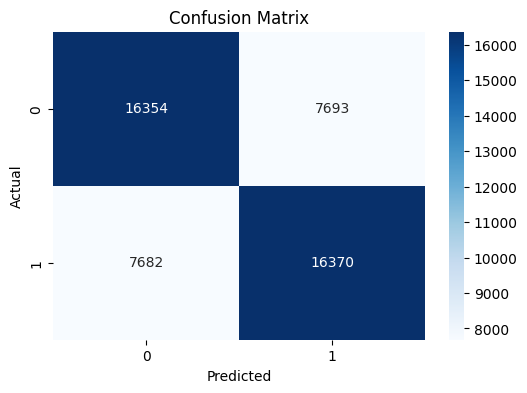

Balanced Accuracy: 0.680
Log Loss: 0.592
Brier Score: 0.204


In [31]:
#Confusion matrix
cm = confusion_matrix(actuals, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Accuracy
accuracy = balanced_accuracy_score(actuals, predictions)
print(f"Balanced Accuracy: {accuracy:.3f}")

#Log loss
logloss = log_loss(actuals, probabilities)
print(f"Log Loss: {logloss:.3f}")

#Brier score
brier_score = brier_score_loss(actuals, probabilities)
print(f"Brier Score: {brier_score:.3f}")


                Feature  Coefficient  Abs_Coefficient
6      elo_diff_surface     0.486373         0.486373
5              elo_diff     0.431898         0.431898
8         complete_diff     0.294926         0.294926
9             form_diff    -0.241834         0.241834
0             rank_diff    -0.183052         0.183052
2              age_diff    -0.151833         0.151833
1      rank_points_diff     0.081618         0.081618
7  serve_advantage_diff     0.068021         0.068021
3           height_diff     0.065271         0.065271
4        different_hand    -0.012979         0.012979


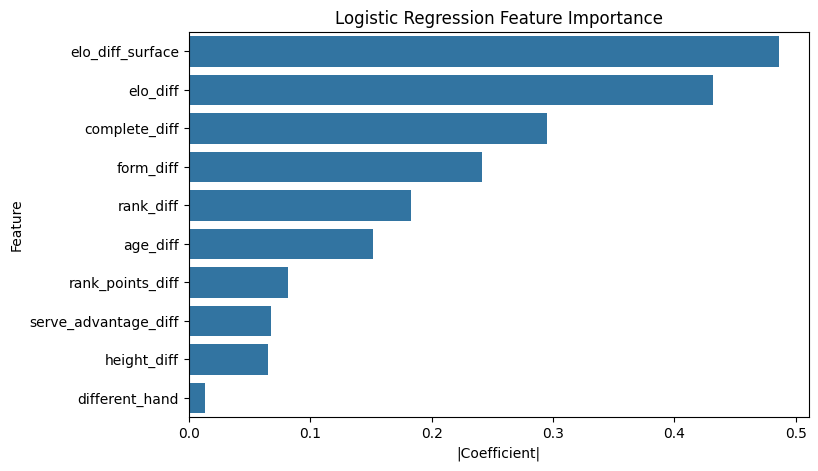

In [32]:
#RQ2: FEATURE IMPORTANCE

#Model fit and clf coefficients
pipe.fit(df[X], df[y])
coefficients = pipe.named_steps["clf"].coef_[0]

feature_importance_logit = pd.DataFrame({
    "Feature": X,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
}).sort_values(by="Abs_Coefficient", ascending=False)

print(feature_importance_logit)

#Visualization
plt.figure(figsize=(8,5))
sns.barplot(
    data=feature_importance_logit,
    x="Abs_Coefficient",
    y="Feature"
)
plt.title("Logistic Regression Feature Importance")
plt.xlabel("|Coefficient|")
plt.ylabel("Feature")
plt.show()



In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

features = [
    "elo_diff",
    "elo_diff_surface",
    "serve_advantage_diff",
    "complete_diff",
    "form_diff"
]

X_scaled = StandardScaler().fit_transform(df[features])

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained = pca.explained_variance_ratio_

# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(features))],
    index=features
)

print(loadings)
print(explained)

                           PC1       PC2       PC3       PC4       PC5
elo_diff              0.486145 -0.295762 -0.252629  0.510938 -0.592713
elo_diff_surface      0.451675 -0.387487 -0.524382 -0.482893  0.371054
serve_advantage_diff  0.431454 -0.303361  0.799004 -0.278745 -0.075586
complete_diff         0.376361  0.736040 -0.102342 -0.411580 -0.369765
form_diff             0.481511  0.358603  0.111002  0.508585  0.607100
[0.71250773 0.17000616 0.07803142 0.023312   0.01614269]
